In [7]:
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import numpy as np

# Get all CSV files in the current directory
csv_files = glob.glob("*.csv")
print(f"Found CSV files: {csv_files}")

# Read all CSV files into a dictionary
dataframes = {}
for file in csv_files:
    # Extract the name without extension for the key
    name = os.path.splitext(file)[0]
    dataframes[name] = pd.read_csv(file)
    print(f"Loaded {file}: {dataframes[name].shape}")

# Display info about each dataframe
for name, df in dataframes.items():
    print(f"\n{name}:")
    print(df.head())
    print(f"Shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")

Found CSV files: ['info_sacchmyc.csv', 'info_DPANN.csv', 'info_ara.csv', 'info_cyano.csv', 'info_asgard.csv', 'info_strep.csv']
Loaded info_sacchmyc.csv: (1253, 5)
Loaded info_DPANN.csv: (100076, 5)
Loaded info_ara.csv: (6398, 5)
Loaded info_cyano.csv: (55788, 5)
Loaded info_asgard.csv: (51004, 5)
Loaded info_strep.csv: (142713, 5)

info_sacchmyc:
                                            name    scores          id  \
0  scoring/dir_001/AF-A0A023PID0-F1-model_v4.pdb  0.043487  A0A023PID0   
1  scoring/dir_001/AF-A0A023PJU7-F1-model_v4.pdb  0.024432  A0A023PJU7   
2  scoring/dir_001/AF-A0A023PXQ9-F1-model_v4.pdb  0.009118  A0A023PXQ9   
3  scoring/dir_001/AF-A0A023PZL2-F1-model_v4.pdb  0.002803  A0A023PZL2   
4  scoring/dir_001/AF-A0A096ZM56-F1-model_v4.pdb  0.012299  A0A096ZM56   

                                            sequence  \
0  ECPVMHKSSSSKCPVMQADTEQINPLNNMPELTAARQPGQKLDLPA...   
1  FSPPEFPPLSPLERSGAVALDNILPLEWYPLRPEFFESTYFLYRAT...   
2  METNDSDDRIEAIVSEESDELEVNSGTTEETNVL

No organisms with >= 1000 entries for info_sacchmyc


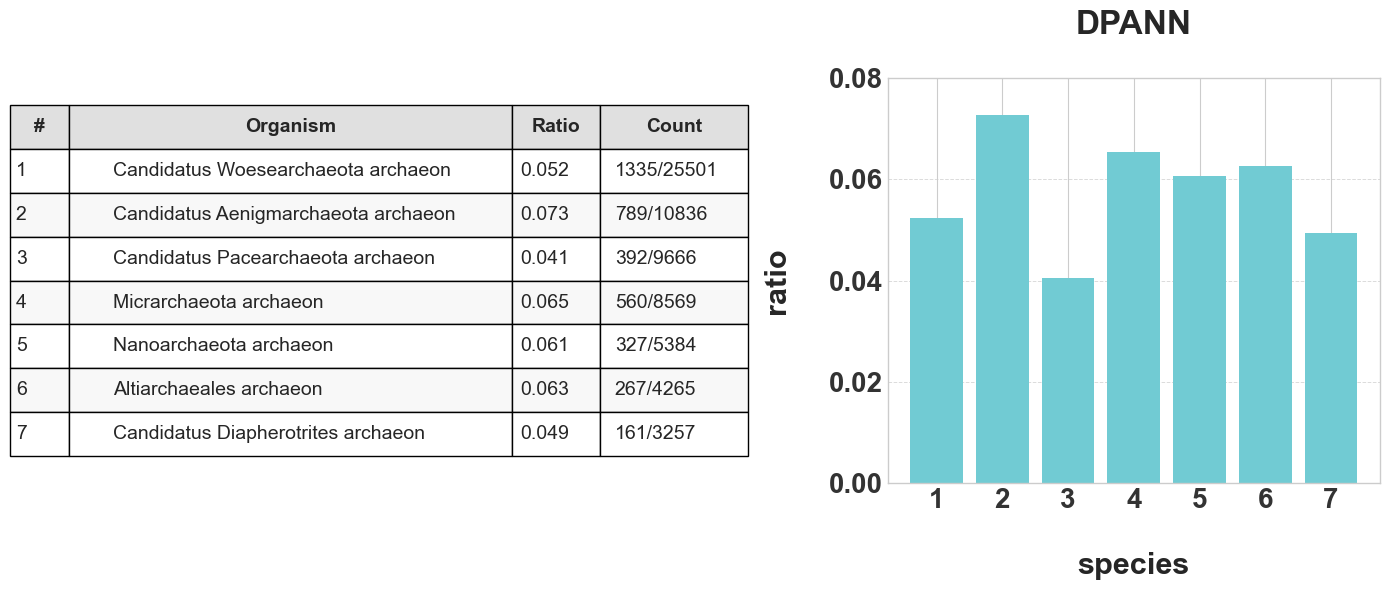


DPANN Summary:
  Total entries: 100076
  Entries after filtering (>= 1000): 67478
  Top 7 organisms by count:
    1. Candidatus Woesearchaeota archaeon: 0.052 (1335/25501)
    2. Candidatus Aenigmarchaeota archaeon: 0.073 (789/10836)
    3. Candidatus Pacearchaeota archaeon: 0.041 (392/9666)
    4. Micrarchaeota archaeon: 0.065 (560/8569)
    5. Nanoarchaeota archaeon: 0.061 (327/5384)
    6. Altiarchaeales archaeon: 0.063 (267/4265)
    7. Candidatus Diapherotrites archaeon: 0.049 (161/3257)


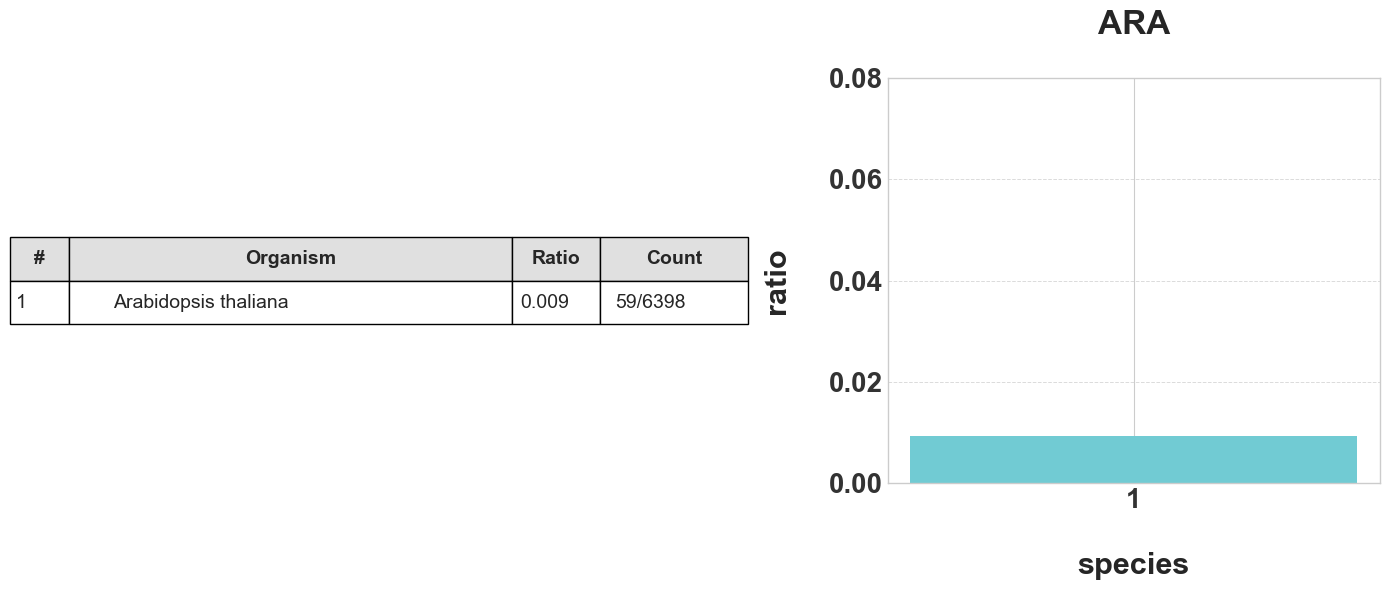


ARA Summary:
  Total entries: 6398
  Entries after filtering (>= 1000): 6398
  Top 7 organisms by count:
    1. Arabidopsis thaliana: 0.009 (59/6398)


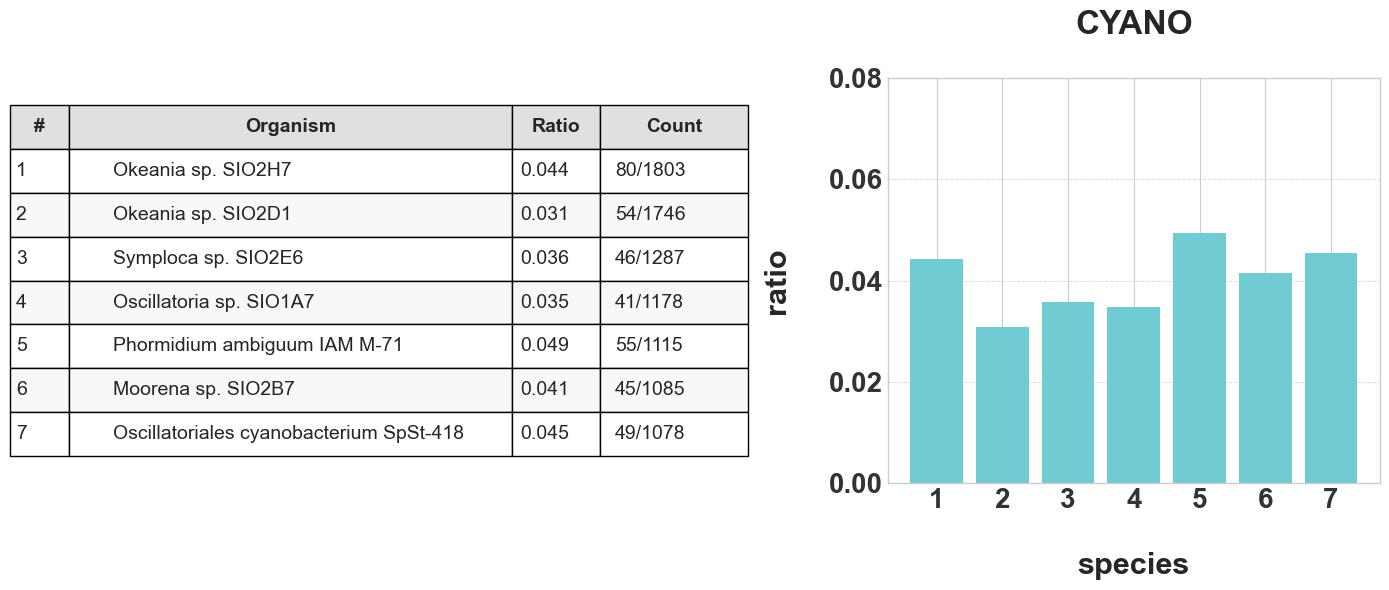


CYANO Summary:
  Total entries: 55788
  Entries after filtering (>= 1000): 11386
  Top 7 organisms by count:
    1. Okeania sp. SIO2H7: 0.044 (80/1803)
    2. Okeania sp. SIO2D1: 0.031 (54/1746)
    3. Symploca sp. SIO2E6: 0.036 (46/1287)
    4. Oscillatoria sp. SIO1A7: 0.035 (41/1178)
    5. Phormidium ambiguum IAM M-71: 0.049 (55/1115)
    6. Moorena sp. SIO2B7: 0.041 (45/1085)
    7. Oscillatoriales cyanobacterium SpSt-418: 0.045 (49/1078)


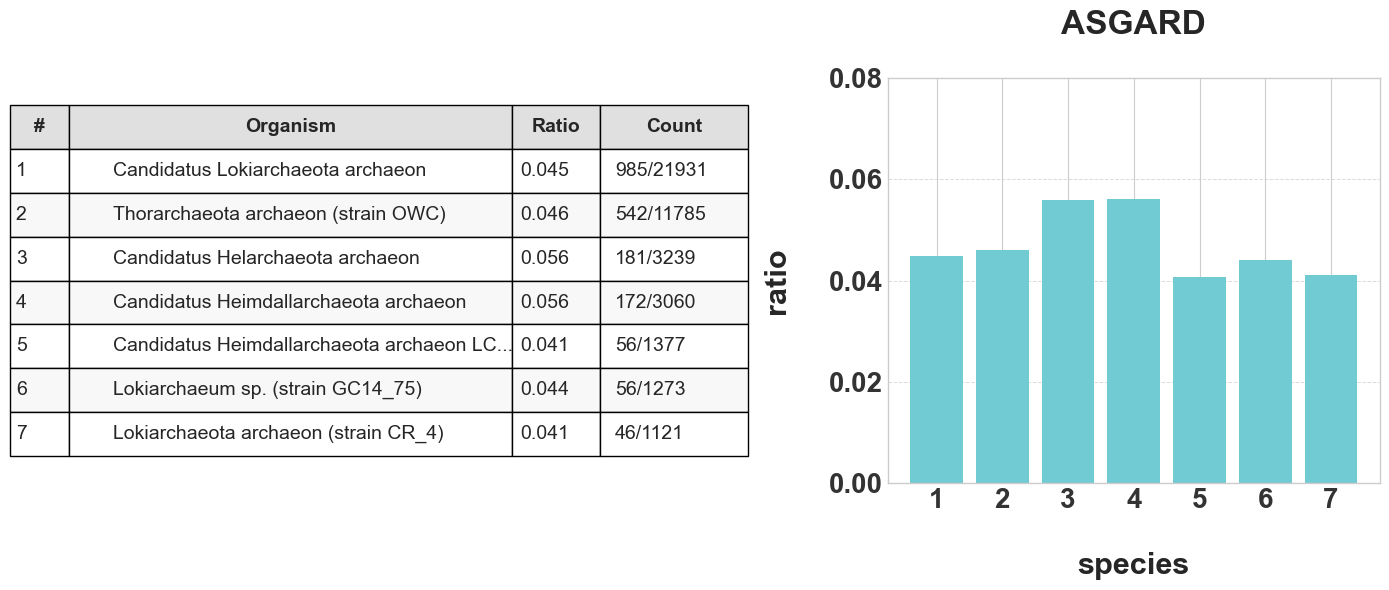


ASGARD Summary:
  Total entries: 51004
  Entries after filtering (>= 1000): 44887
  Top 7 organisms by count:
    1. Candidatus Lokiarchaeota archaeon: 0.045 (985/21931)
    2. Thorarchaeota archaeon (strain OWC): 0.046 (542/11785)
    3. Candidatus Helarchaeota archaeon: 0.056 (181/3239)
    4. Candidatus Heimdallarchaeota archaeon: 0.056 (172/3060)
    5. Candidatus Heimdallarchaeota archaeon LC_3: 0.041 (56/1377)
    6. Lokiarchaeum sp. (strain GC14_75): 0.044 (56/1273)
    7. Lokiarchaeota archaeon (strain CR_4): 0.041 (46/1121)


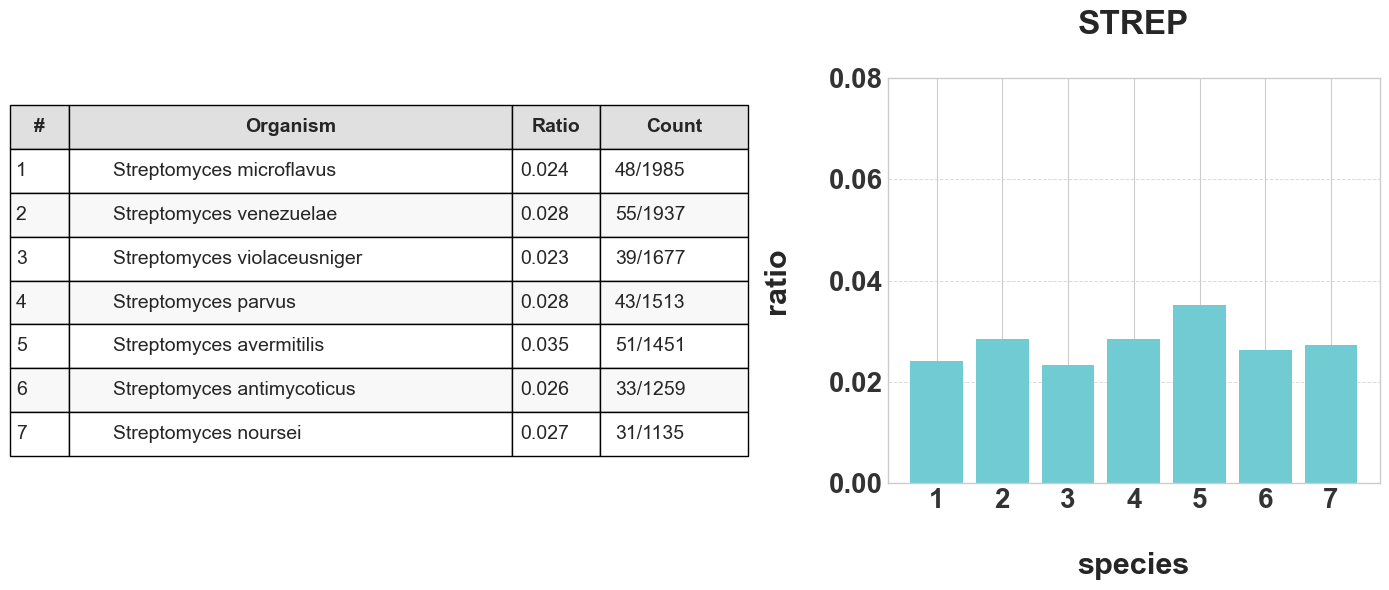


STREP Summary:
  Total entries: 142713
  Entries after filtering (>= 1000): 18279
  Top 7 organisms by count:
    1. Streptomyces microflavus: 0.024 (48/1985)
    2. Streptomyces venezuelae: 0.028 (55/1937)
    3. Streptomyces violaceusniger: 0.023 (39/1677)
    4. Streptomyces parvus: 0.028 (43/1513)
    5. Streptomyces avermitilis: 0.035 (51/1451)
    6. Streptomyces antimycoticus: 0.026 (33/1259)
    7. Streptomyces noursei: 0.027 (31/1135)


In [8]:
# Create individual plots for each dataframe following the exact format
def create_individual_plots(dataframes, score_col_name='scores', os_col_name='OS', STD_COLOR='0.2'):
    
    for name, df in dataframes.items():
        if score_col_name not in df.columns or os_col_name not in df.columns:
            print(f"Skipping {name}: missing required columns")
            continue
            
        # Extract org name from dataframe name
        org = name.replace('info_', '').upper()
        
        # Process data following exact format
        score_table = df.copy()
        
        # Merge sequence_x data
        os_counts = score_table[os_col_name].value_counts().reset_index()
        os_counts.columns = [os_col_name, 'count']
        score_table = score_table.merge(os_counts, on=os_col_name, how='left')
        
        # Calculate denovolikeness based on score
        score_table['denovo'] = (score_table[score_col_name] > 0.5).astype(int)
        
        # Filter rows with count >= 1000
        score = score_table[score_table['count'] >= 1000]
        
        if len(score) == 0:
            print(f"No organisms with >= 1000 entries for {name}")
            continue
            
        # Denovo per organism
        denovo_counts = score[score['denovo'] == 1].groupby(os_col_name).size().reset_index(name='denovo_count')
        score = score.merge(denovo_counts, on=os_col_name, how='left')
        score['denovo_count'] = score['denovo_count'].fillna(0).astype(int)
        
        # Create publication-ready figure
        plt.style.use('seaborn-v0_8-whitegrid')
        
        # Calculate statistics
        grouped = score.groupby(os_col_name).agg({
            'denovo_count': 'first',
            'count': 'first'
        }).reset_index()
        
        grouped['ratio'] = grouped['denovo_count'] / grouped['count']
        grouped['error'] = np.sqrt((grouped['ratio'] * (1 - grouped['ratio'])) / grouped['count'])
        
        # Filter to top 7 biggest counts
        grouped = grouped.nlargest(7, 'count')
        
        # Create figure with subplots: table on left, bar chart on right
        fig, (ax_table, ax_bar) = plt.subplots(1, 2, figsize=(14, 6), 
                                               gridspec_kw={'width_ratios': [1, 1]})
        
        # Create table data
        table_data = []
        for i, (_, row) in enumerate(grouped.iterrows()):
            table_data.append([
                f"{i+1}",
                row[os_col_name][:40] + "..." if len(row[os_col_name]) > 40 else row[os_col_name],
                f"{row['ratio']:.3f}",
                f"{row['denovo_count']}/{row['count']}"
            ])
        
        # Create table
        ax_table.axis('tight')
        ax_table.axis('off')
        
        table = ax_table.table(cellText=table_data,
                              colLabels=['#', 'Organism', 'Ratio', 'Count'],
                              cellLoc='left',
                              loc='center',
                              colWidths=[0.08, 0.6, 0.12, 0.2])
        
        # Style the table
        table.auto_set_font_size(False)
        table.set_fontsize(14)
        table.scale(1.5, 3)
        
        # Style header
        for i in range(4):
            table[(0, i)].set_facecolor('#E0E0E0')
            table[(0, i)].set_text_props(weight='bold')
        
        # Style rows with alternating colors
        for i in range(1, len(table_data) + 1):
            if i % 2 == 0:
                for j in range(4):
                    table[(i, j)].set_facecolor('#F8F8F8')
        
        # Create bar plot
        bars = ax_bar.bar(range(len(grouped)), grouped['ratio'], color='#71cbd3', width=0.8)
        
        # Customize the bar plot
        ax_bar.set_xticks(range(len(grouped)))
        ax_bar.set_xticklabels([str(i+1) for i in range(len(grouped))], fontsize=20, fontweight='bold')
        ax_bar.tick_params(axis='y', labelsize=20, colors=STD_COLOR)
        
        # Make y-axis labels bold to match x-axis style
        for label in ax_bar.get_yticklabels():
            label.set_fontweight('bold')
        ax_bar.set_xlabel('\nspecies', fontsize=22, fontweight='bold')
        ax_bar.set_ylabel('ratio\n', fontsize=22, fontweight='bold')
        ax_bar.set_title(f'{org}\n', fontsize=24, fontweight='bold')
        ax_bar.set_ylim(0, 0.08)
        
        # Add gridlines for better readability
        ax_bar.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)
        ax_bar.tick_params(axis='x', colors=STD_COLOR)
        ax_bar.tick_params(axis='y', colors=STD_COLOR)
        
        # Add summary information as text annotation
        total_entries = len(score_table)
        filtered_entries = len(score)
        unique_organisms = len(grouped)
        
        # Calculate overall statistics
        total_denovo = score_table['denovo'].sum()
        overall_ratio = total_denovo / total_entries if total_entries > 0 else 0
        
        
        # Show the plot
        plt.tight_layout()
        plt.savefig(f'dist_{org}.png', bbox_inches='tight', dpi=300)
        plt.show()
        
        # Print summary
        print(f"\n{org} Summary:")
        print(f"  Total entries: {len(score_table)}")
        print(f"  Entries after filtering (>= 1000): {len(score)}")
        print(f"  Top 7 organisms by count:")
        for i, (_, row) in enumerate(grouped.iterrows()):
            print(f"    {i+1}. {row[os_col_name]}: {row['ratio']:.3f} ({row['denovo_count']}/{row['count']})")

# Create the individual plots
STD_COLOR = '0.2'
create_individual_plots(dataframes)